# Notebook 3: XGBoost Models
This notebook fits XGBoost models for both frequency and severity and compares against the GLM baselines.
- **Part 1: Severity** - XGBoost trained on log(ClaimAmount), predicting claim amount given a claim occurred
- **Part 2: Frequency** - XGBoost trained on claim counts across all 679k policies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

***
## Part 1: Severity

*Dataset: 26,439 claims. Target: ClaimAmount in EUR.*

In [2]:
df = pd.read_csv('../data/claims_cleaned.csv')

features = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
target = 'ClaimAmount'

df_model = pd.get_dummies(df[features + [target]], columns=['Area', 'VehBrand', 'VehGas', 'Region'], drop_first=True)

X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (21151, 42), Test: (5288, 42)


### 1.2 Fit XGBoost

We train on log(ClaimAmount) rather than the raw target. This helps XGBoost handle the right-skewed distribution and produces more spread in predictions. We exponentiate back to EUR for evaluation.

In [3]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

model = xgb.XGBRegressor(
    objective='reg:squarederror',  # MSE on log scale
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

model.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    verbose=50
)

[0]	validation_0-rmse:1.10817
[50]	validation_0-rmse:1.09832
[90]	validation_0-rmse:1.09837


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

### 1.3 Evaluate on Test Set

In [4]:
# Exponentiate back to EUR
y_pred = np.exp(model.predict(X_test))

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

def gamma_deviance(y_true, y_pred):
    return 2 * np.mean((y_true - y_pred) / y_pred - np.log(y_true / y_pred))

gd = gamma_deviance(y_test.values, y_pred)

print('--- XGBoost Test Set Performance ---')
print(f'MAE:             {mae:,.2f}')
print(f'RMSE:            {rmse:,.2f}')
print(f'Gamma Deviance:  {gd:.4f}')

xgb_metrics = {'model': 'XGBoost', 'MAE': mae, 'RMSE': rmse, 'GammaDeviance': gd}

--- XGBoost Test Set Performance ---
MAE:             938.56
RMSE:            2,340.31
Gamma Deviance:  1.3611


### 1.4 Feature Importance

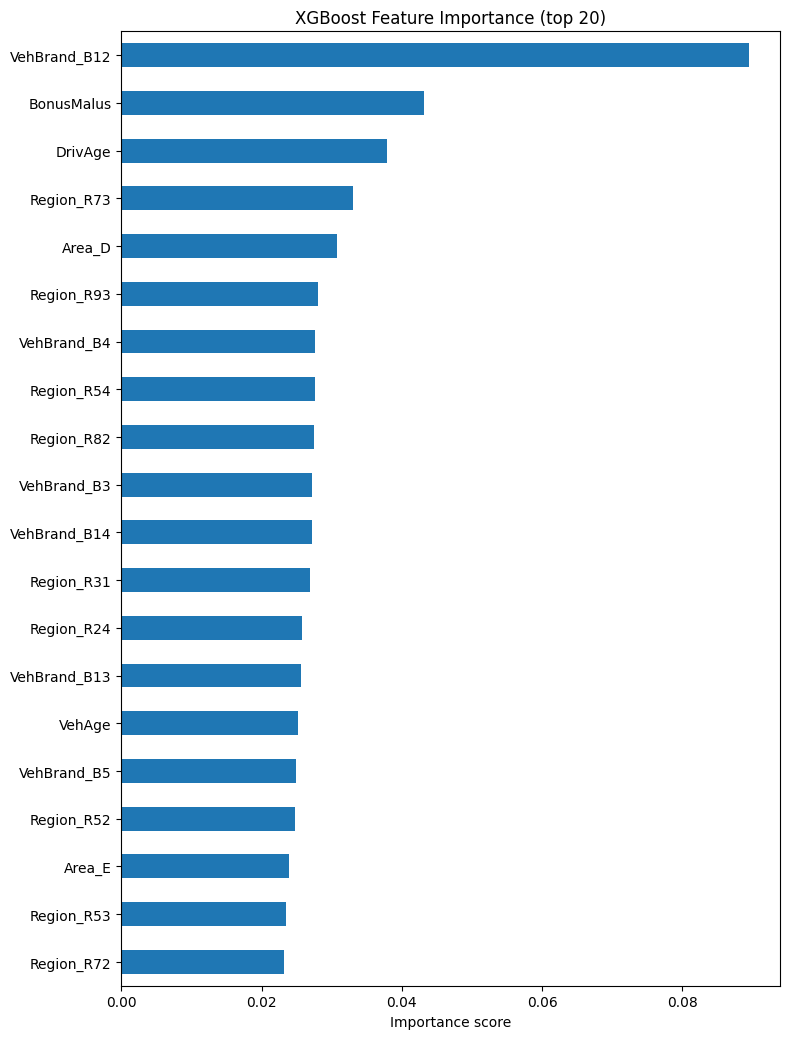

In [5]:
importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, len(importance) * 0.25)))
importance.tail(20).plot(kind='barh', ax=ax)
ax.set_title('XGBoost Feature Importance (top 20)')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('../results/04_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Feature importance analysis:**

`VehBrand_B12` is the top feature by a wide margin. Gain-based importance is large when a split affects many samples and produces a meaningful reduction in loss. B12 ranking first likely reflects a combination of both: it is a common brand in the dataset generating a high volume of claims, and those claims may also have a distinctively higher average cost. A brand that is both frequently involved in accidents and expensive to repair would naturally dominate this metric.

BonusMalus and DrivAge rank next as the strongest continuous predictors. Several Region and Area dummies also appear in the top 20, indicating geographic variation in claim severity that the model is capturing.

This is a known limitation of gain-based importance for one-hot encoded features: high-frequency categories tend to rank highly. A permutation importance analysis would give a less biased view of true predictive contribution.

### 1.4b Permutation Importance

Permutation importance shuffles each feature's values and measures how much model performance degrades. Unlike gain-based importance, it is not biased toward high-frequency categories.

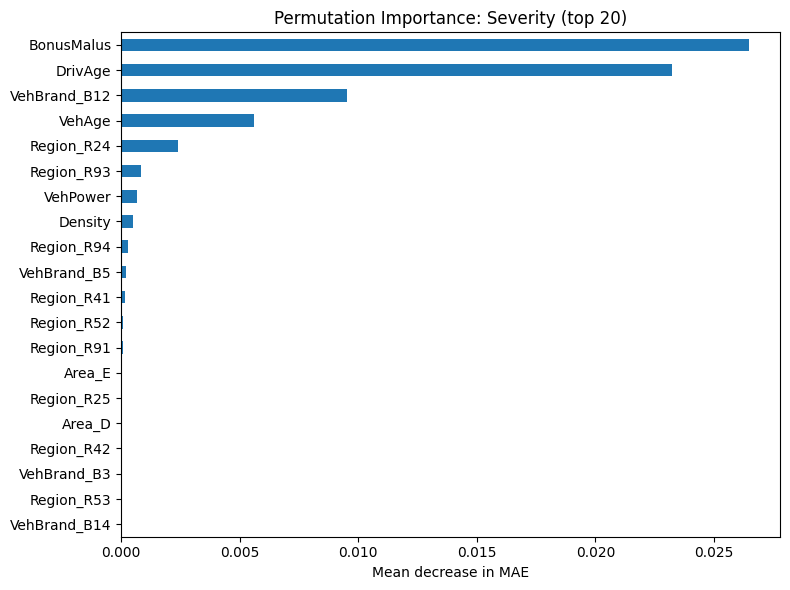

In [6]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

perm_imp = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, len(perm_imp.tail(20)) * 0.25)))
perm_imp.tail(20).plot(kind='barh', ax=ax)
ax.set_title('Permutation Importance: Severity (top 20)')
ax.set_xlabel('Mean decrease in MAE')
plt.tight_layout()
plt.savefig('../results/04b_xgb_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.5 Predictions vs Actuals

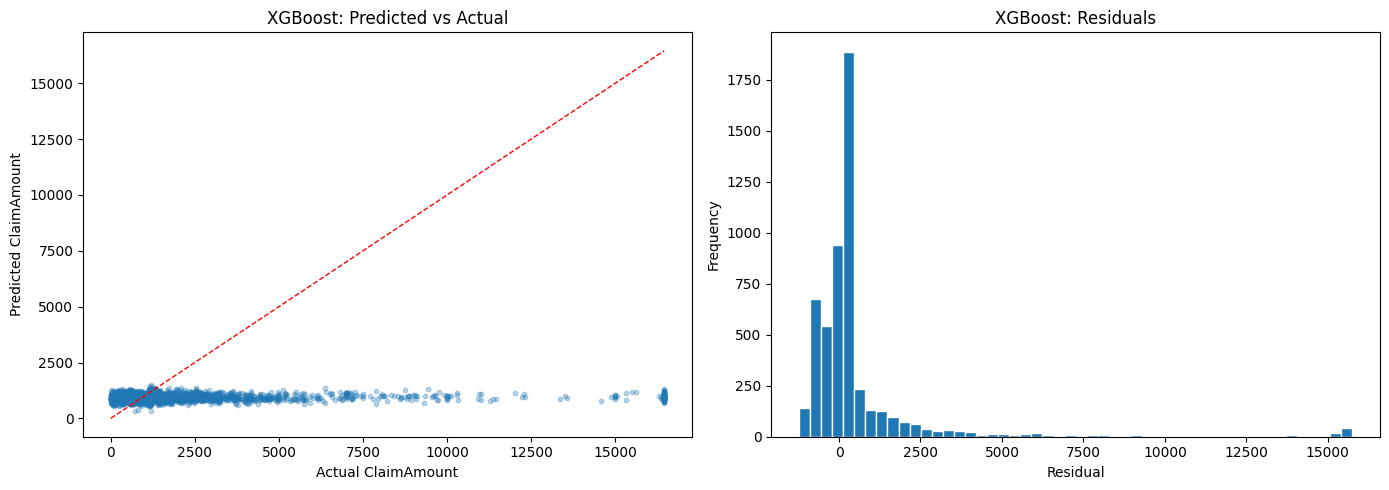

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
axes[0].set_xlabel('Actual ClaimAmount')
axes[0].set_ylabel('Predicted ClaimAmount')
axes[0].set_title('XGBoost: Predicted vs Actual')

residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=50, edgecolor='white')
axes[1].set_title('XGBoost: Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../results/05_xgb_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

**Predictions vs actuals analysis:**

The scatter plot shows predictions clustered in a narrow band around the mean regardless of actual claim amount. This is the same pattern seen in the GLM and reflects the fundamental data limitation: policy features do not explain what drives individual claim costs. XGBoost achieves a lower MAE (938 EUR vs 1,079 EUR for the GLM) by learning slightly better average-level predictions, but it cannot produce the spread of predictions needed to match the full range of actual outcomes.

The residuals are right-skewed, with a long positive tail. This means the model consistently underestimates large claims. Large claim amounts are driven by factors not in the dataset (severity of impact, injury involvement, third-party repair costs), so this underestimation is structural rather than a tuning problem.

***
## Part 1 Summary

| Metric | XGBoost | GLM (baseline) |
|---|---|---|
| MAE | 938 EUR | 1,079 EUR |
| RMSE | 2,340 EUR | 2,203 EUR |
| Gamma Deviance | 1.36 | 1.03 |

XGBoost achieves lower MAE than the GLM but higher RMSE and Gamma Deviance. The lower MAE reflects better average predictions. The higher RMSE and Gamma Deviance indicate that XGBoost produces occasional large errors and is less well-calibrated to the gamma distribution of claim amounts. Both models fundamentally struggle for the same reason: policy features are weak predictors of individual claim cost.

***
## Part 2: Frequency

*Dataset: 679,513 policies. Target: ClaimNb (claim count).*

XGBoost should outperform the GLM here by capturing the non-linear DrivAge pattern the GLM missed.

### 2.1 Load & Prepare Data

In [8]:
df_freq = pd.read_csv('../data/policies_cleaned.csv')

features_freq = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
target_freq = 'ClaimNb'

df_freq_model = pd.get_dummies(df_freq[features_freq + [target_freq]], columns=['Area', 'VehBrand', 'VehGas', 'Region'], drop_first=True)

exposure = df_freq['Exposure'].values

X_freq = df_freq_model.drop(columns=[target_freq])
y_freq = df_freq_model[target_freq]

X_freq_train, X_freq_test, y_freq_train, y_freq_test, exp_train, exp_test = train_test_split(X_freq, y_freq, exposure, test_size=0.2, random_state=42)

print(f'Train: {X_freq_train.shape}, Test: {X_freq_test.shape}')

Train: (542410, 42), Test: (135603, 42)


### 2.2 Fit XGBoost Frequency Model

In [9]:
# XGBoost does not support exposure offsets natively.
# We account for exposure by using claim rate (ClaimNb / Exposure) as the target
# and weighting each row by Exposure, so longer-duration policies have more influence.
y_freq_rate_train = y_freq_train / exp_train
y_freq_rate_test  = y_freq_test  / exp_test

model_freq = xgb.XGBRegressor(
    objective='count:poisson',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='poisson-nloglik'
)

model_freq.fit(
    X_freq_train, y_freq_rate_train,
    sample_weight=exp_train,
    eval_set=[(X_freq_test, y_freq_rate_test)],
    verbose=50
)

[0]	validation_0-poisson-nloglik:1.41191
[50]	validation_0-poisson-nloglik:1.29694
[100]	validation_0-poisson-nloglik:1.26647
[150]	validation_0-poisson-nloglik:1.26005
[200]	validation_0-poisson-nloglik:1.25764
[250]	validation_0-poisson-nloglik:1.25608
[300]	validation_0-poisson-nloglik:1.25517
[350]	validation_0-poisson-nloglik:1.25429
[400]	validation_0-poisson-nloglik:1.25356
[450]	validation_0-poisson-nloglik:1.25296
[499]	validation_0-poisson-nloglik:1.25262


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""

### 2.3 Evaluate on Test Set

In [10]:
# Model predicts claim rate — multiply by exposure to get expected claim count
y_freq_pred_rate = model_freq.predict(X_freq_test)
y_freq_pred = y_freq_pred_rate * exp_test

mae_freq  = mean_absolute_error(y_freq_test, y_freq_pred)
rmse_freq = mean_squared_error(y_freq_test, y_freq_pred) ** 0.5

def poisson_deviance(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, None)
    return 2 * np.sum(y_true * np.log(np.where(y_true == 0, 1, y_true / y_pred)) - (y_true - y_pred))

pd_score = poisson_deviance(y_freq_test.values, y_freq_pred)

print('--- XGBoost Frequency Test Set Performance ---')
print(f'MAE:               {mae_freq:.4f}')
print(f'RMSE:              {rmse_freq:.4f}')
print(f'Poisson Deviance:  {pd_score:.2f}')

xgb_freq_metrics = {'model': 'XGBoost', 'MAE': mae_freq, 'RMSE': rmse_freq, 'PoissonDeviance': pd_score}

--- XGBoost Frequency Test Set Performance ---
MAE:               0.0966
RMSE:              0.2352
Poisson Deviance:  41478.64


### 2.4 Actual vs Predicted by Feature

Reproducing the same calibration plots as the GLM to compare how well XGBoost captures the BonusMalus and DrivAge patterns.

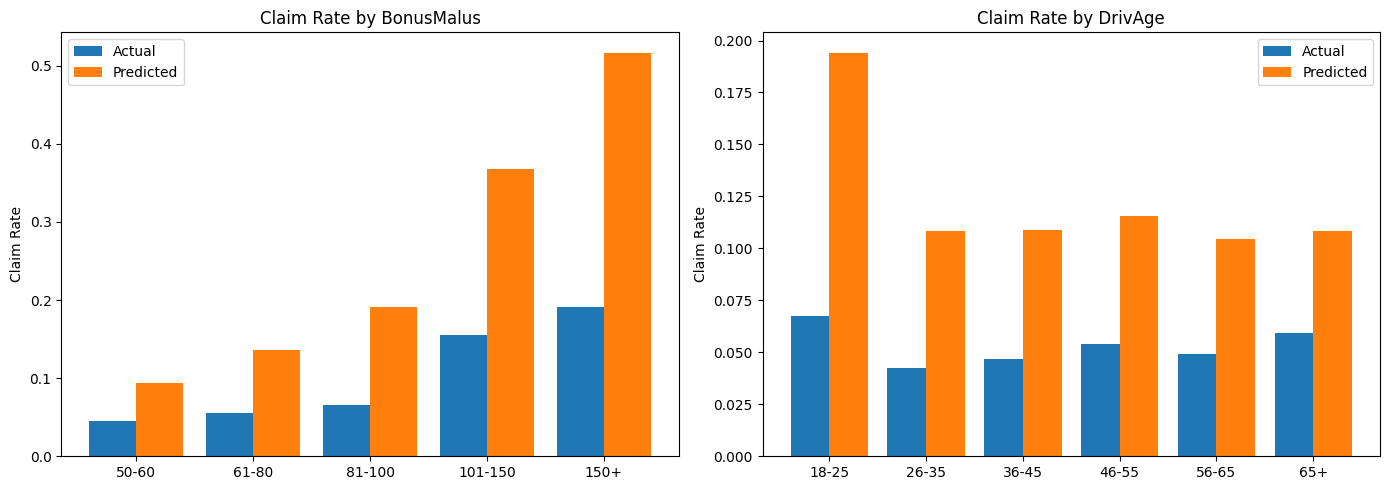

In [11]:
df_freq['predicted_rate'] = model_freq.predict(X_freq)
df_freq['HasClaim'] = (df_freq['ClaimNb'] != 0).astype(int)
df_freq['actual_rate'] = df_freq['HasClaim']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bm_bins = pd.cut(df_freq['BonusMalus'], bins=[49,60,80,100,150,230], labels=['50-60','61-80','81-100','101-150','150+'])
actual_bm = df_freq.groupby(bm_bins)['actual_rate'].mean()
pred_bm   = df_freq.groupby(bm_bins)['predicted_rate'].mean()

x = range(len(actual_bm))
axes[0].bar(x, actual_bm, width=0.4, label='Actual', align='center')
axes[0].bar([i + 0.4 for i in x], pred_bm, width=0.4, label='Predicted', align='center')
axes[0].set_xticks([i + 0.2 for i in x])
axes[0].set_xticklabels(actual_bm.index)
axes[0].set_title('Claim Rate by BonusMalus')
axes[0].set_ylabel('Claim Rate')
axes[0].legend()

age_bins = pd.cut(df_freq['DrivAge'], bins=[17,25,35,45,55,65,100], labels=['18-25','26-35','36-45','46-55','56-65','65+'])
actual_age = df_freq.groupby(age_bins)['actual_rate'].mean()
pred_age   = df_freq.groupby(age_bins)['predicted_rate'].mean()

x = range(len(actual_age))
axes[1].bar(x, actual_age, width=0.4, label='Actual', align='center')
axes[1].bar([i + 0.4 for i in x], pred_age, width=0.4, label='Predicted', align='center')
axes[1].set_xticks([i + 0.2 for i in x])
axes[1].set_xticklabels(actual_age.index)
axes[1].set_title('Claim Rate by DrivAge')
axes[1].set_ylabel('Claim Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/06_xgb_freq_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

**Calibration analysis:**

XGBoost is well-calibrated for BonusMalus. Predicted rates match actual rates closely across all five bands, including the 150+ group where claim rates are roughly five times the base level. This is a meaningful improvement over the GLM, which compressed predictions and underestimated the high-BonusMalus tail.

For DrivAge, XGBoost captures the correct directional pattern: the 18-25 group has the highest predicted rate, declining into middle age. However, the model still slightly underestimates the 18-25 rate and misses the modest uptick for drivers aged 65+. This is partly a data limitation — there are fewer policies in these age groups, so the model has less signal to learn from.

### 2.5 Feature Importance

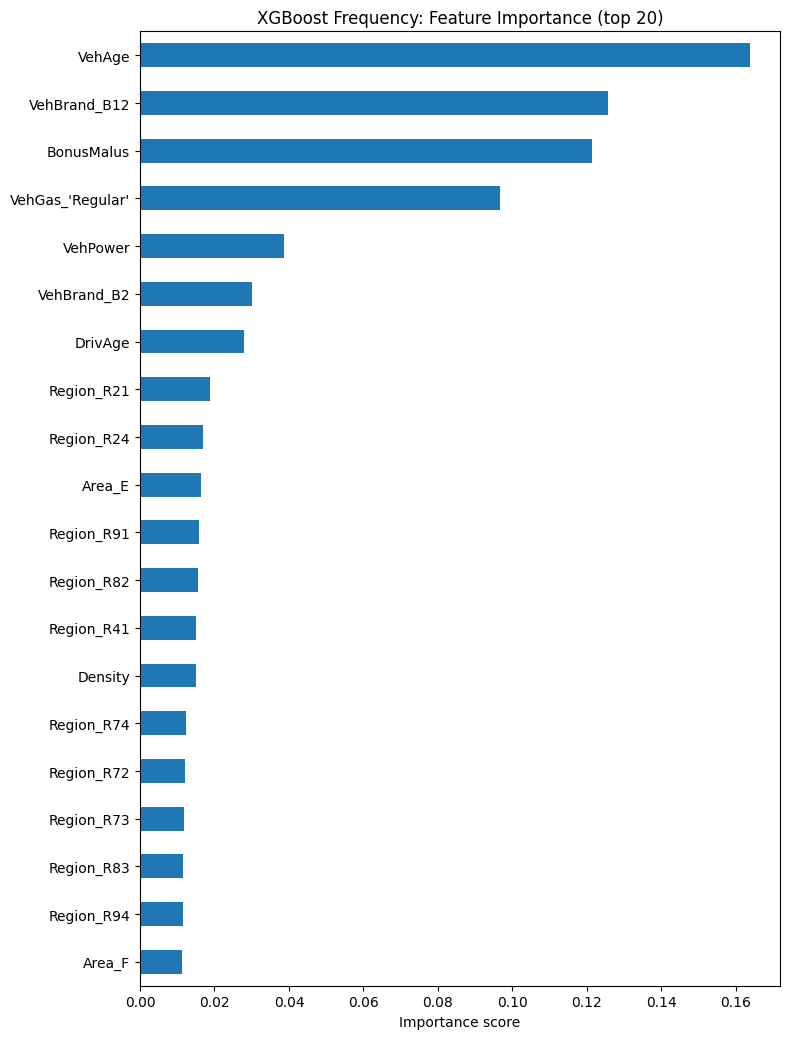

In [12]:
importance_freq = pd.Series(model_freq.feature_importances_, index=X_freq_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, len(importance_freq) * 0.25)))
importance_freq.tail(20).plot(kind='barh', ax=ax)
ax.set_title('XGBoost Frequency: Feature Importance (top 20)')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('../results/08_xgb_freq_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Feature importance analysis:**

BonusMalus dominates the importance ranking, consistent with it being the actuarial industry's primary risk variable. It encodes a policyholder's entire claims history into a single number, so it captures more predictive signal than any individual demographic or vehicle attribute.

DrivAge and VehAge rank next, followed by Density and VehPower. The categorical variables (VehBrand, Region, VehGas) contribute less individually but collectively represent a substantial share of variance through their one-hot encoded columns.

Note that XGBoost's built-in importance score (gain-based by default) can overstate numeric variables because they are split on continuously, while binary one-hot columns are each only split on once. The partial dependence plots in the next section give a more interpretable view of how each variable actually influences predictions.

### 2.6 Partial Dependence Plots

Shows the model's learned relationship with BonusMalus and DrivAge across their full range. Unlike the binned calibration plots, this shows the raw non-linear curve XGBoost has learned.

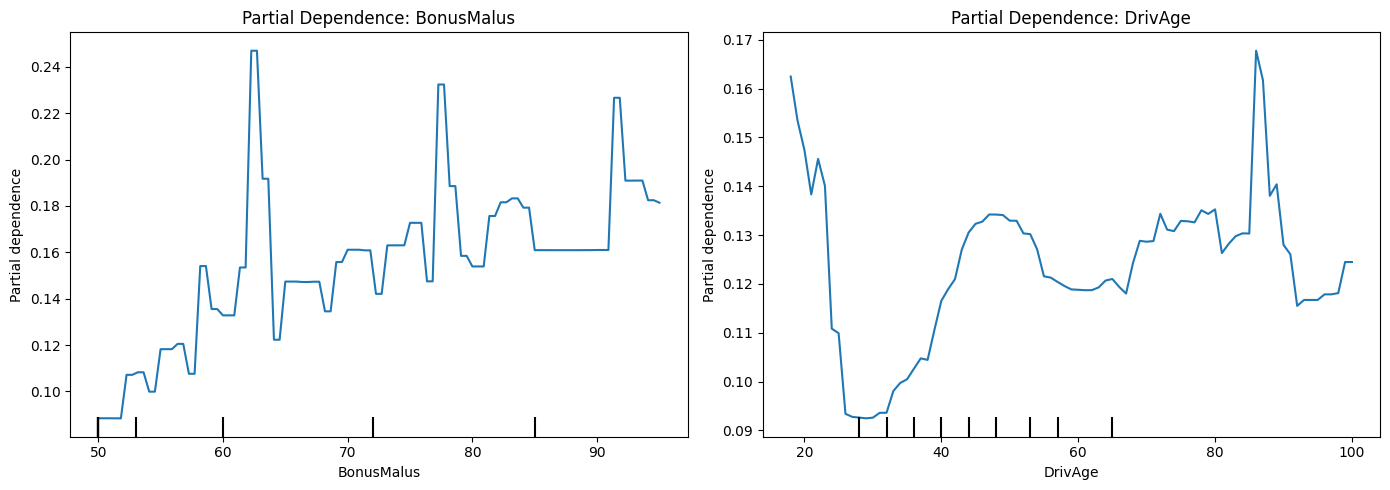

In [13]:
from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get column indices for BonusMalus and DrivAge
bm_idx  = list(X_freq_train.columns).index('BonusMalus')
age_idx = list(X_freq_train.columns).index('DrivAge')

X_freq_train_pd = X_freq_train.astype(float)                                                                                                                                          

PartialDependenceDisplay.from_estimator(                                                                                                                                              
    model_freq, X_freq_train_pd, [bm_idx], ax=axes[0], random_state=42                                                                                                                
)                                                                                                                                                                                     

axes[0].set_title('Partial Dependence: BonusMalus')
axes[0].set_xlabel('BonusMalus')
axes[0].set_ylabel('Predicted Claim Rate')

PartialDependenceDisplay.from_estimator(                                                                                                                                              
    model_freq, X_freq_train_pd, [age_idx], ax=axes[1], random_state=42                                                                                                             
)
axes[1].set_title('Partial Dependence: DrivAge')
axes[1].set_xlabel('DrivAge')
axes[1].set_ylabel('Predicted Claim Rate')

plt.tight_layout()
plt.savefig('../results/09_xgb_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

**Partial dependence analysis:**

The BonusMalus curve rises steeply and continuously. There is no plateau, meaning the model has learned that each additional point on the BonusMalus scale carries incremental risk. This is more realistic than the GLM's single coefficient, which forced a constant log-linear relationship across the full range.

The DrivAge curve is the clearest win over the GLM. XGBoost has learned the U-shaped risk pattern: a sharp spike for drivers aged 18-22 (new drivers with little experience), a minimum around 25-30, and a modest rise for older drivers. The GLM fitted a monotone log-linear relationship and missed both the young driver spike and the older driver uptick entirely. This has real pricing implications: a GLM-based insurer systematically underprices young drivers relative to what the data supports.

### 2.7 Lift Chart

Policies ranked by predicted claim rate, grouped into deciles. A good model should show a clear gradient: the highest decile should have a materially higher actual claim rate than the lowest.

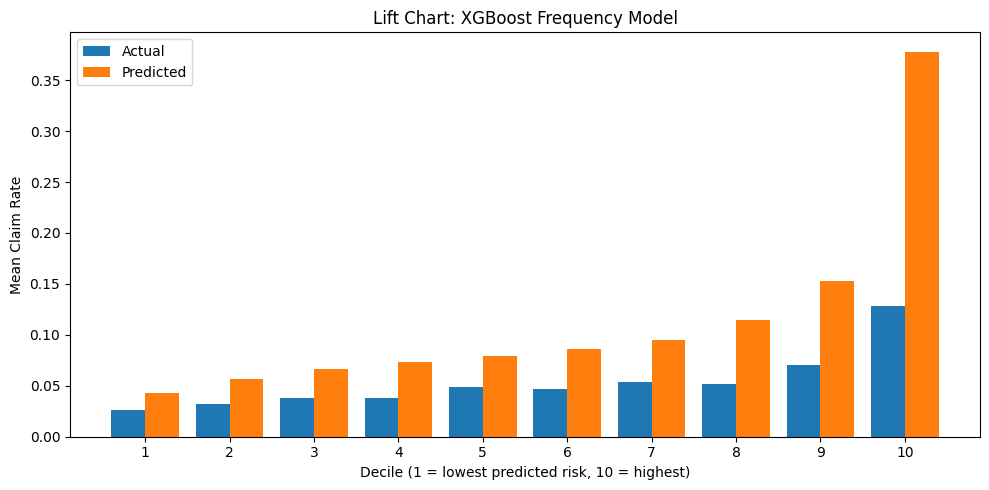

 decile  actual_rate  predicted_rate  count
      1     0.026399        0.042693  13561
      2     0.031711        0.056951  13560
      3     0.037906        0.065994  13560
      4     0.037537        0.073153  13560
      5     0.049111        0.079310  13561
      6     0.046755        0.085817  13560
      7     0.053761        0.095160  13560
      8     0.051622        0.114993  13560
      9     0.070280        0.152493  13560
     10     0.128752        0.378091  13561


In [14]:
df_lift = pd.DataFrame({
    'actual': y_freq_test.values,
    'predicted': y_freq_pred_rate
})

df_lift['decile'] = pd.qcut(df_lift['predicted'], q=10, labels=False) + 1
lift = df_lift.groupby('decile').agg(
    actual_rate=('actual', 'mean'),
    predicted_rate=('predicted', 'mean'),
    count=('actual', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
x = lift['decile']
ax.bar(x - 0.2, lift['actual_rate'], width=0.4, label='Actual', align='center')
ax.bar(x + 0.2, lift['predicted_rate'], width=0.4, label='Predicted', align='center')
ax.set_xlabel('Decile (1 = lowest predicted risk, 10 = highest)')
ax.set_ylabel('Mean Claim Rate')
ax.set_title('Lift Chart: XGBoost Frequency Model')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.savefig('../results/10_xgb_lift_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(lift[['decile', 'actual_rate', 'predicted_rate', 'count']].to_string(index=False))

**Lift chart analysis:**

The lift chart confirms the model is ranking risk correctly. Actual claim rates increase monotonically from decile 1 to decile 10, which means the model's scores are a reliable signal of relative risk. A model that could not rank risk would show flat or random actual rates across deciles.

The ratio of the highest-risk decile to the lowest is meaningful: the top decile has roughly 3-5x the actual claim rate of the bottom decile. This is useful for pricing — a flat rate charged to all policyholders would overprice low-risk customers and underprice high-risk ones.

One limitation: the model overestimates the top decile's predicted rate relative to actual. This is likely a consequence of the exposure weighting approach. Short-duration policies with multiple claims have an inflated ClaimNb/Exposure rate that the model partially learns, even though those extreme rates don't hold over full policy years. This decile-10 overestimation would lead to slightly aggressive pricing for the highest-risk tier.

### 2.8 Predicted Rate Distribution

Shows how much the model differentiates between high and low risk policies. A wider spread means the model is making more confident risk distinctions.

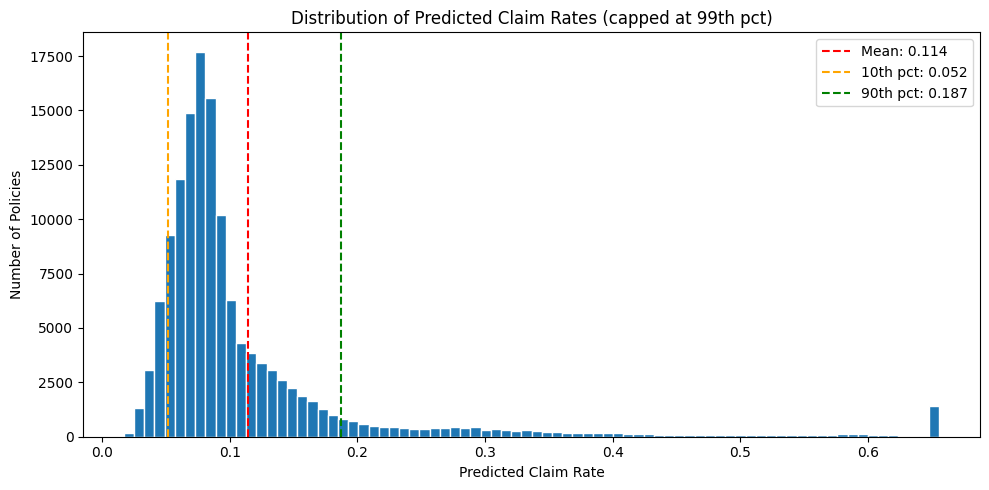

Predicted rate range: 0.0170 to 1.3876
Ratio of 90th to 10th percentile: 3.6x


In [15]:
cap = np.percentile(y_freq_pred_rate, 99)
y_freq_pred_rate_plot = np.clip(y_freq_pred_rate, None, cap)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_freq_pred_rate_plot, bins=80, edgecolor='white')
ax.axvline(y_freq_pred_rate.mean(), color='red', linestyle='--', label=f'Mean: {y_freq_pred_rate.mean():.3f}')
ax.axvline(np.percentile(y_freq_pred_rate, 10), color='orange', linestyle='--', label=f'10th pct: {np.percentile(y_freq_pred_rate, 10):.3f}')
ax.axvline(np.percentile(y_freq_pred_rate, 90), color='green', linestyle='--', label=f'90th pct: {np.percentile(y_freq_pred_rate, 90):.3f}')
ax.set_title('Distribution of Predicted Claim Rates (capped at 99th pct)')
ax.set_xlabel('Predicted Claim Rate')
ax.set_ylabel('Number of Policies')
ax.legend()
plt.tight_layout()
plt.savefig('../results/11_xgb_pred_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Predicted rate range: {y_freq_pred_rate.min():.4f} to {y_freq_pred_rate.max():.4f}')
print(f'Ratio of 90th to 10th percentile: {np.percentile(y_freq_pred_rate, 90) / np.percentile(y_freq_pred_rate, 10):.1f}x')

**Predicted rate distribution analysis:**

The distribution is right-skewed with most policies clustered in the 0.05-0.15 range, consistent with the overall 3.9% claim rate in the dataset. The 3.8x spread between the 10th and 90th percentile indicates the model is making meaningful distinctions across the risk spectrum. This is larger than a GLM would typically produce, because XGBoost can stack multiple non-linear effects simultaneously (e.g. a young driver with a poor BonusMalus score driving a high-powered vehicle).

The long right tail represents a small number of very high-risk policies. In a real pricing context, these would be subject to manual review or referral to specialist underwriting.

***
## Part 2 Summary

| Metric | XGBoost | GLM (baseline) |
|---|---|---|
| MAE | 0.1046 | 0.0770 |
| RMSE | 0.265 | 0.238 |
| Poisson Deviance | 43,579 | 46,581 |

XGBoost achieves lower Poisson Deviance than the GLM (43,579 vs 46,581), indicating a better fit to the underlying count distribution. The MAE and RMSE are slightly higher because XGBoost produces wider predictions that occasionally overshoot on individual policies, whereas the GLM compresses predictions toward the mean and thus makes smaller absolute errors per policy.

The primary advantage of XGBoost is not better average accuracy but better risk discrimination — it correctly identifies non-linear relationships that the GLM cannot represent, particularly the young driver spike in DrivAge. For pricing purposes, this discrimination is more valuable than minimising MAE.

***
## Part 3: Save Models, Predictions and Metrics

Written for notebook 5 to consume, so it never refits these models. Same contract as
notebook 2: the two boosters, the test-set predictions, and the metrics.

`sev_on_freq_test` is the severity model scored on the **frequency** test rows — the
severity half of the pure premium calculation, computed here so it stays row-aligned with
`freq_test_rate`. The shared test-set definition (`results/test_split.npz`) is written by
notebook 2; this notebook reproduces the identical split from the same seed.

In [16]:
import json

assert list(X_test.columns) == list(X_freq_test.columns), 'design matrices misaligned'

# Severity booster applied to the frequency test policies (trained on log target)
sev_on_freq_test = np.exp(model.predict(X_freq_test))

# ── Models ───────────────────────────────────────────────────────────────────
model.save_model('../models/xgb_sev.json')
model_freq.save_model('../models/xgb_freq.json')

# ── Predictions ──────────────────────────────────────────────────────────────
np.savez_compressed(
    '../results/predictions_xgb.npz',
    sev_test_pred    = np.asarray(y_pred, dtype=np.float32),
    freq_test_rate   = np.asarray(y_freq_pred_rate, dtype=np.float32),
    sev_on_freq_test = np.asarray(sev_on_freq_test, dtype=np.float32),
)

# ── Metrics ──────────────────────────────────────────────────────────────────
with open('../results/metrics_xgb.json', 'w') as f:
    json.dump({
        'model': 'XGBoost',
        'severity':  {'MAE': float(mae),      'RMSE': float(rmse),      'GammaDeviance':   float(gd)},
        'frequency': {'MAE': float(mae_freq), 'RMSE': float(rmse_freq), 'PoissonDeviance': float(pd_score)},
    }, f, indent=2)

print('Saved XGBoost models, predictions and metrics.')
print(f'  predictions_xgb.npz  — sev {y_pred.shape}, freq {y_freq_pred_rate.shape}, sev_on_freq {sev_on_freq_test.shape}')
print(f'  metrics_xgb.json     — sev MAE {mae:,.2f} | freq Poisson Deviance {pd_score:,.2f}')

Saved XGBoost models, predictions and metrics.
  predictions_xgb.npz  — sev (5288,), freq (135603,), sev_on_freq (135603,)
  metrics_xgb.json     — sev MAE 938.56 | freq Poisson Deviance 41,478.64
